<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:
print("--- Dataset Information ---")
print(df.info())


print("\n--- Summary Statistics (Numerical Columns) ---")
print(df.describe())

print("\n--- Summary Statistics (All Columns) ---")
print(df.describe(include='all'))


--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB
None

--- Summary Statistics (Numerical Columns) ---
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65447.000000   3.374000e+04  29659.000000    29325.000000   
mean   32714.001528  2.963841e+145     11.467143       18.580460   
std    18893.063225  5.444117e+147      9.168610       25.966005   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16352.500000   6.000000e+04      4.000000        0.000000   
50%    32714.000000   1.100000e+05      9.000000       10.000000   
75%    49075.500000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29394.000000    29412.000000    29451.000000    29449

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:
missing_all = df.isnull().sum()
print("Missing values per column:")
print(missing_all)

Missing values per column:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64

##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



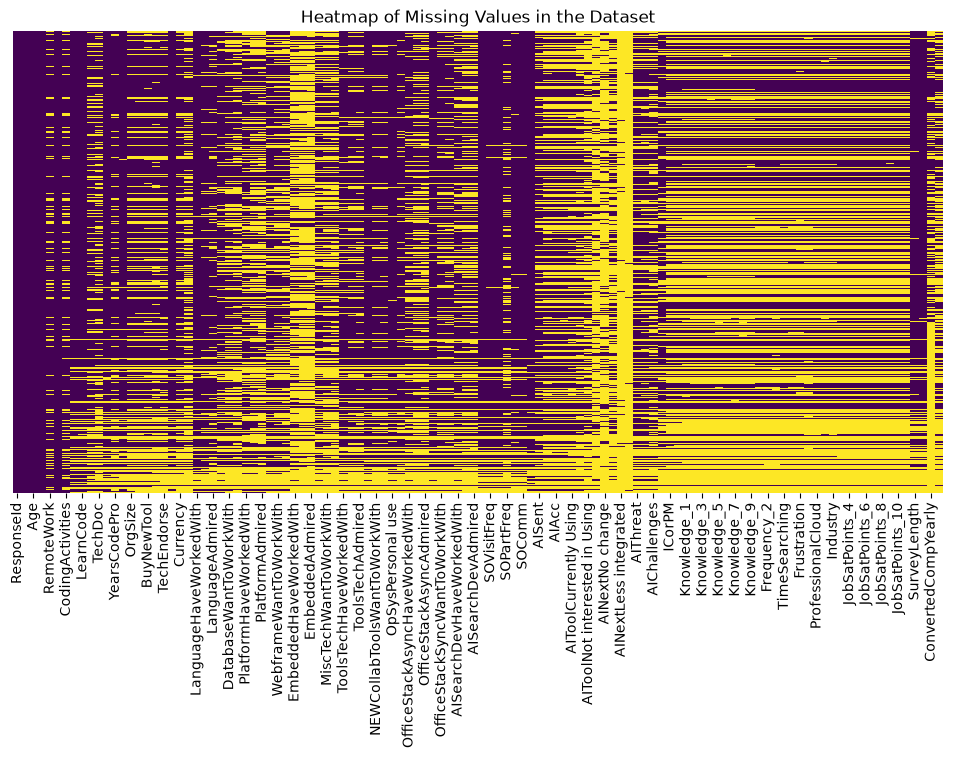

In [6]:
!pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap of Missing Values in the Dataset')
plt.show()

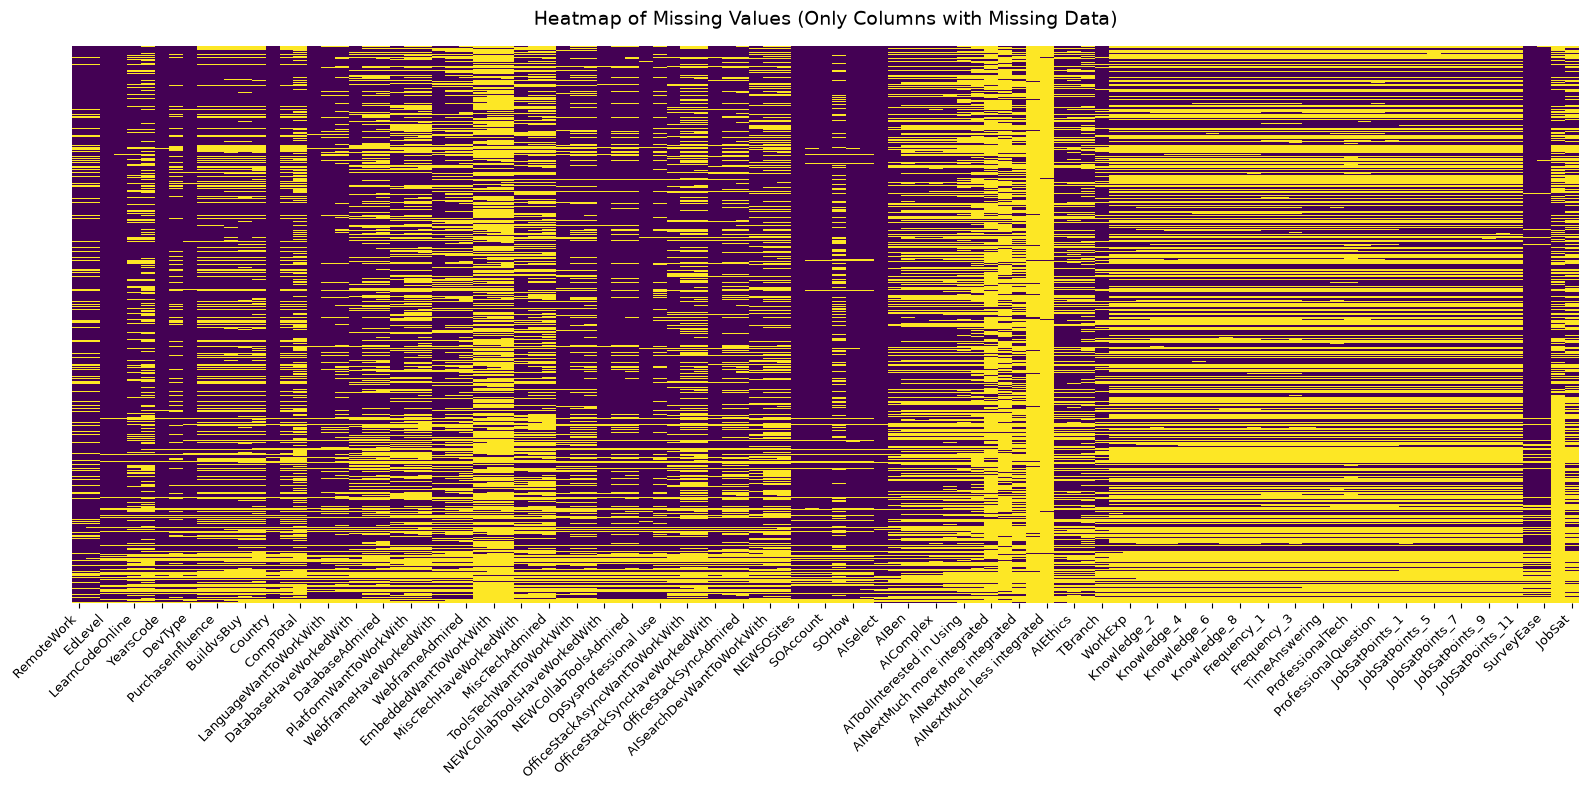

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_with_nas = df.columns[df.isnull().any()]
df_missing_only = df[columns_with_nas]

plt.figure(figsize=(16, 8))  # Wider figure to accommodate labels
sns.heatmap(
    df_missing_only.isnull(), 
    cbar=False, 
    yticklabels=False, 
    cmap='viridis'
)

# Rotate labels and adjust layout so everything is readable
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Heatmap of Missing Values (Only Columns with Missing Data)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [8]:
# Count the number of missing rows for the specific column 'Employment'
missing_employment = df['Employment'].isnull().sum()
print(f"Number of missing rows in 'Employment' column: {missing_employment}")


Number of missing rows in 'Employment' column: 0

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [9]:
# Identify the most frequent value (mode) in the 'Employment' column
most_frequent_employment = df['Employment'].mode()[0]
print(f"The most frequent value in 'Employment' is: {most_frequent_employment}")

The most frequent value in 'Employment' is: Employed, full-time

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [10]:
df['Employment'].fillna(most_frequent_employment, inplace=True)

remaining_missing = df['Employment'].isnull().sum()
print(f"Number of remaining missing values in 'Employment': {remaining_missing}")

Number of remaining missing values in 'Employment': 0

/tmp/ipykernel_1237/1272412745.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Employment'].fillna(most_frequent_employment, inplace=True)

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


/tmp/ipykernel_1237/1391684112.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

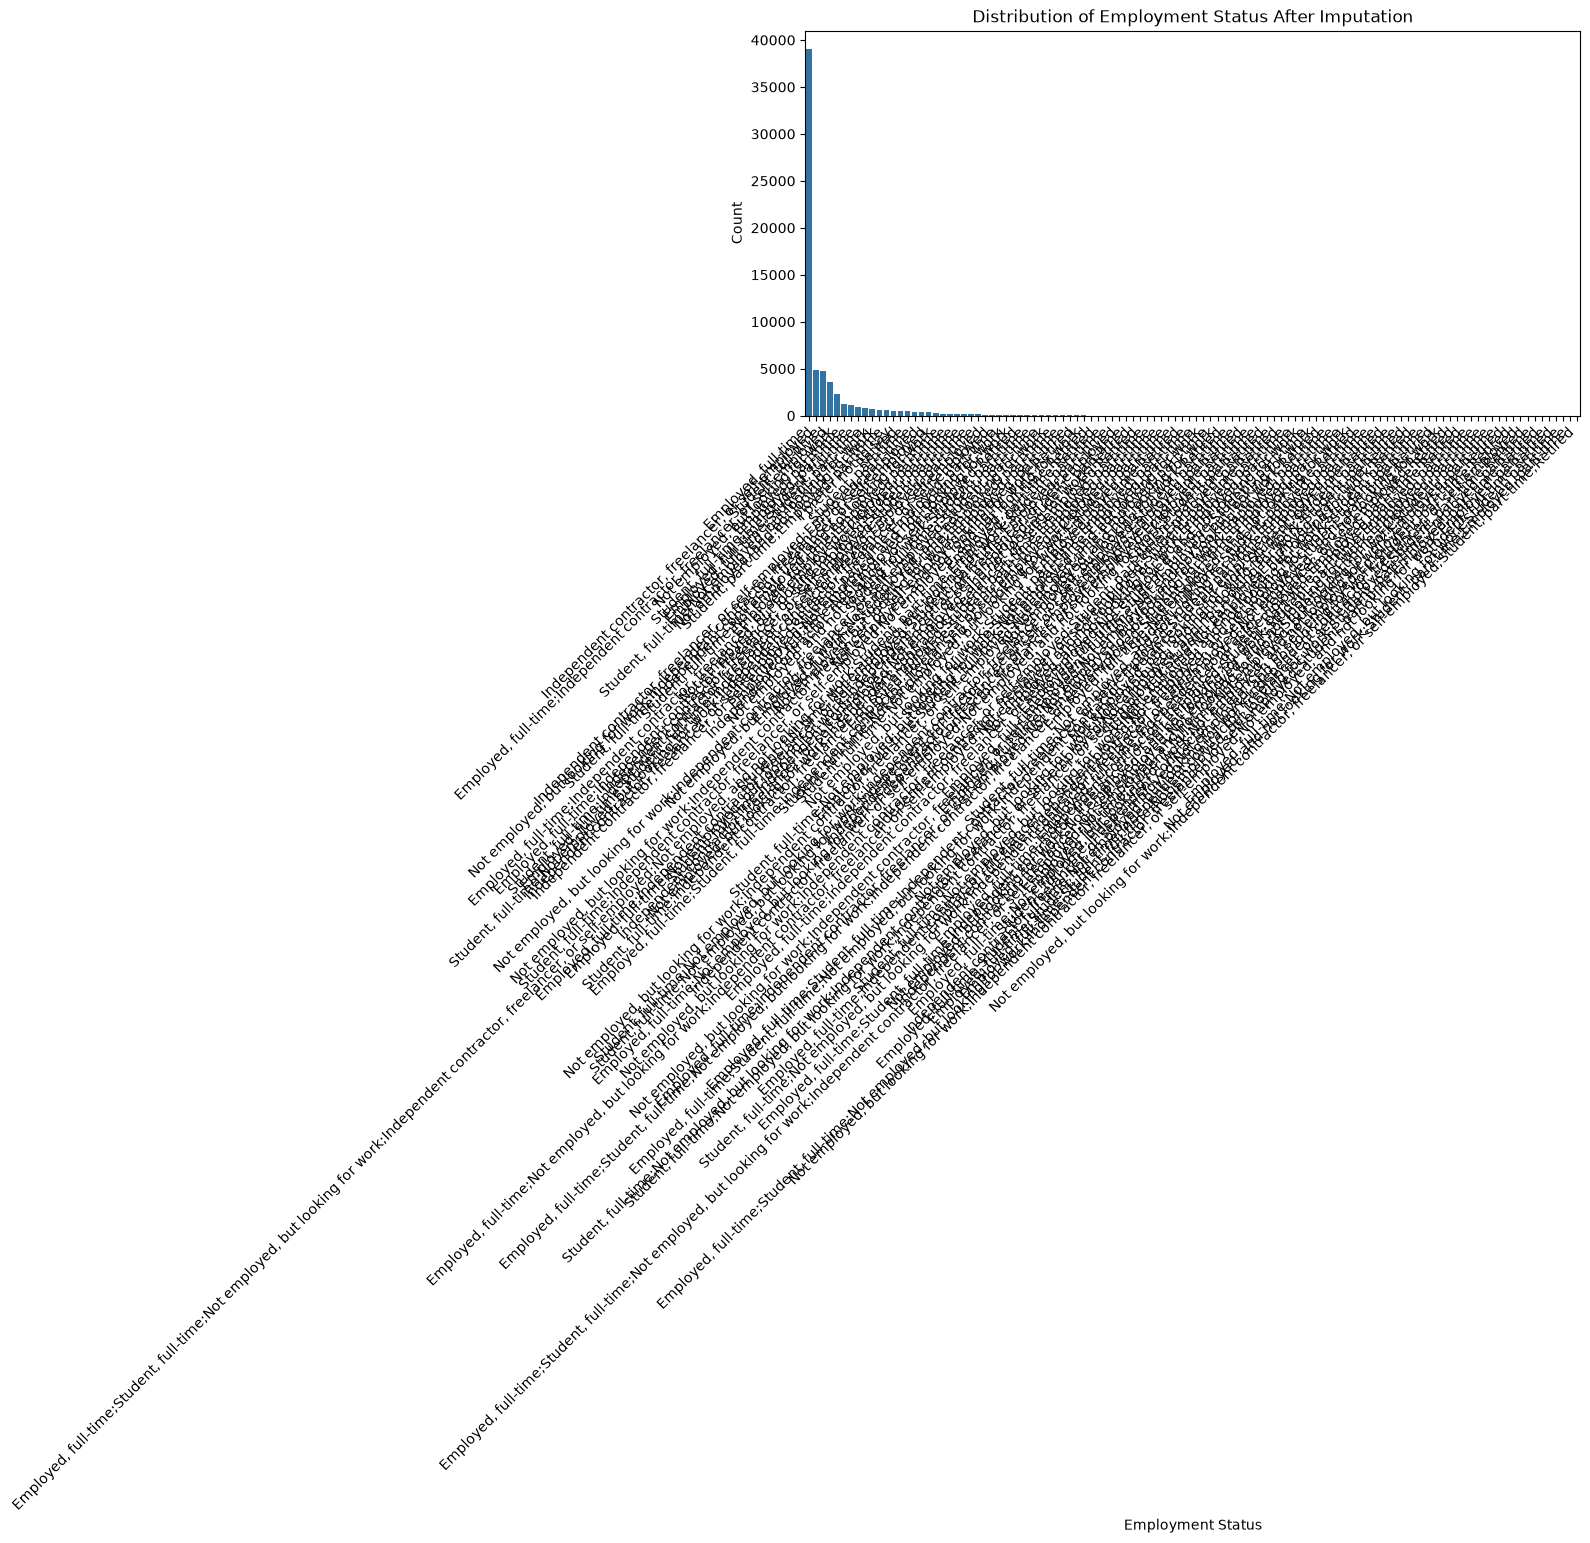

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Employment', order=df['Employment'].value_counts().index)
plt.title('Distribution of Employment Status After Imputation')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

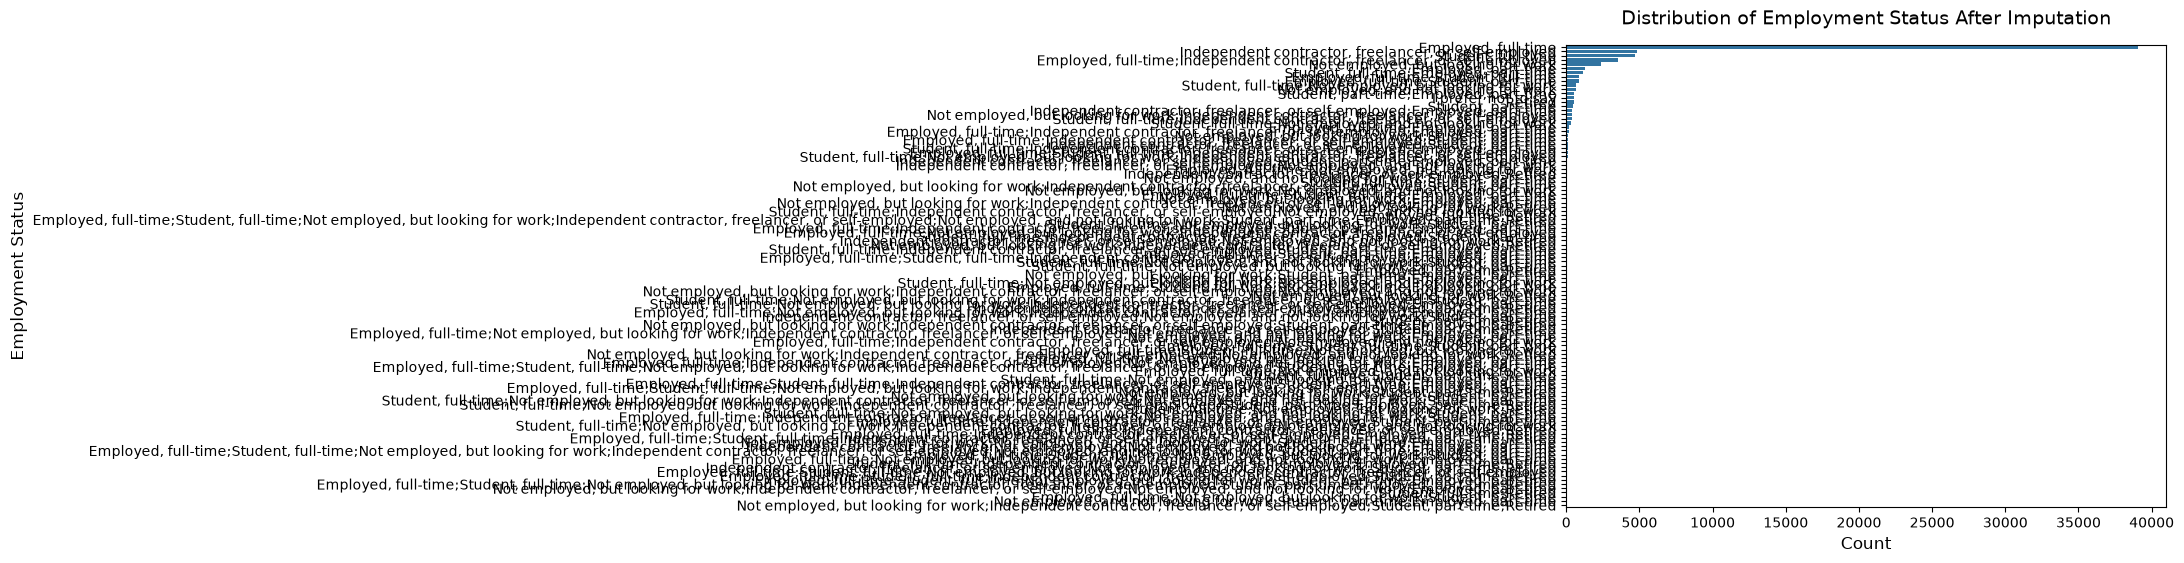

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adjusted width and height for vertical layout
plt.figure(figsize=(12, 6))

# Swapped x with y to make the bar plot horizontal
sns.countplot(
    data=df, 
    y='Employment', 
    order=df['Employment'].value_counts().index
)

# Titles and labels adjustment
plt.title('Distribution of Employment Status After Imputation', fontsize=14, pad=15)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Employment Status', fontsize=12)

# Give padding to the left margin for long text labels
plt.subplots_adjust(left=0.4)

plt.show()

/tmp/ipykernel_1237/3718328428.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

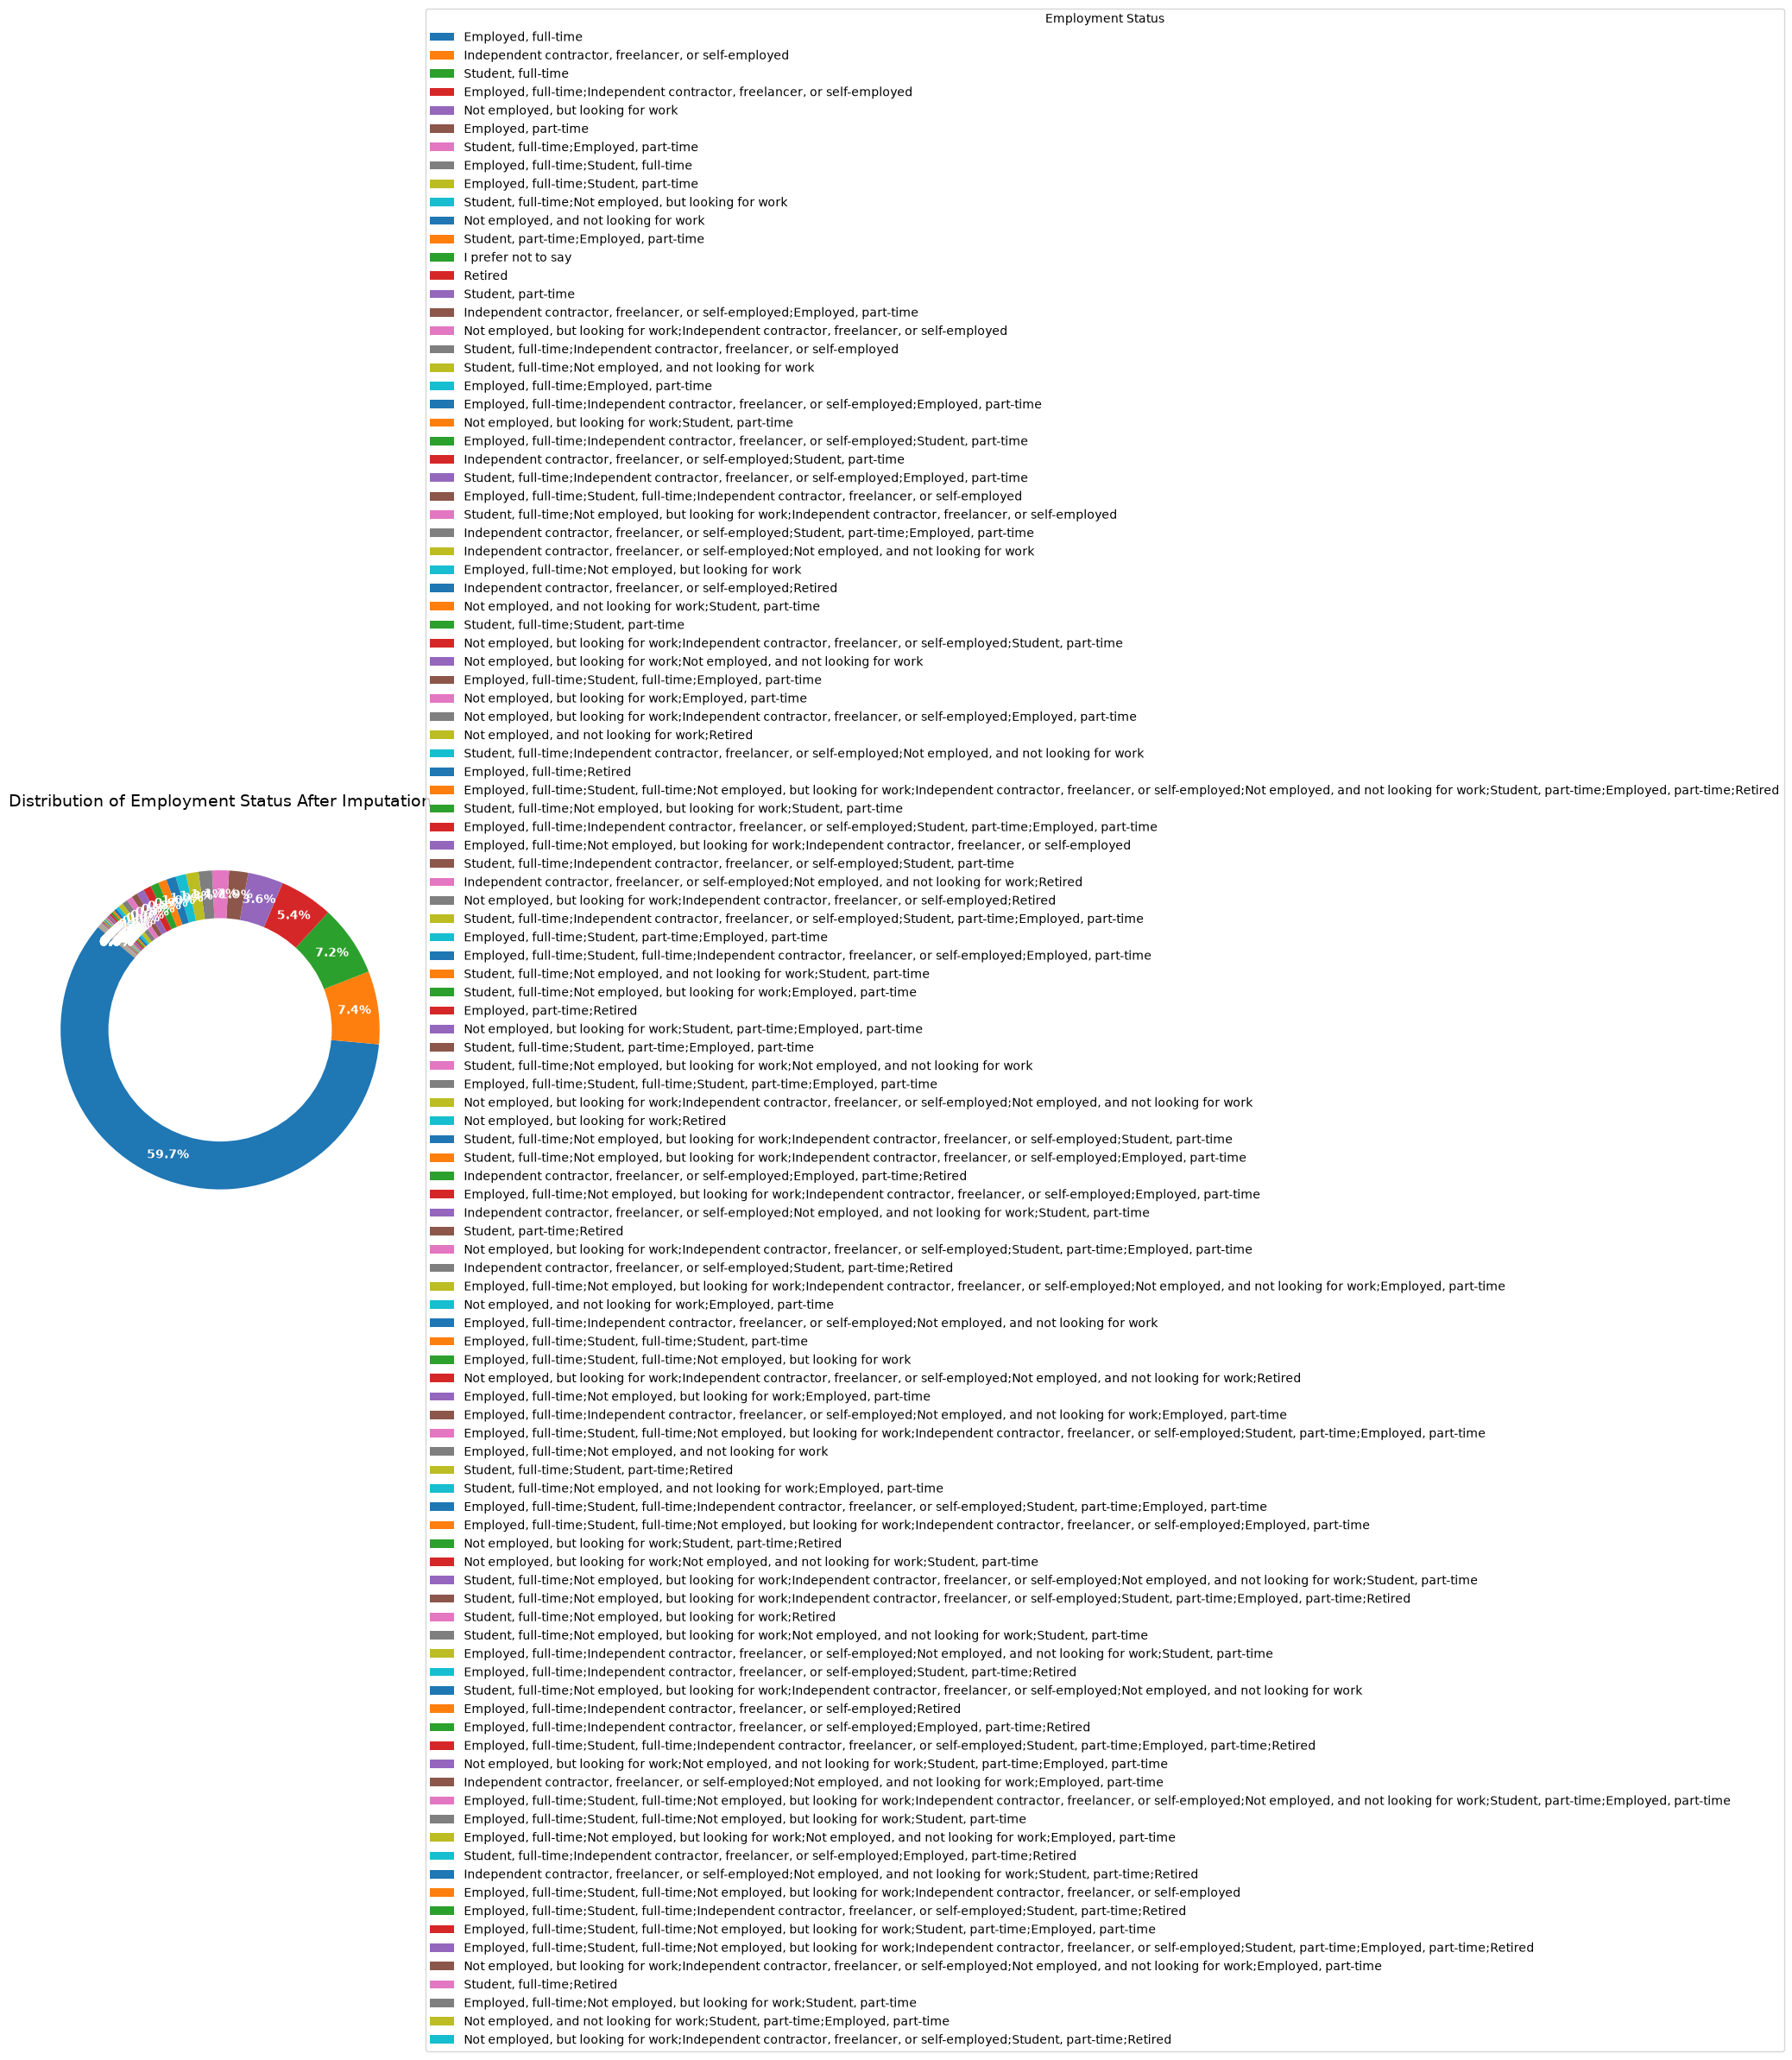

In [14]:
import matplotlib.pyplot as plt

# Prepare data counts and percentages
employment_counts = df['Employment'].value_counts()
labels = employment_counts.index
sizes = employment_counts.values

# Create figure and pie/donut chart
fig, ax = plt.subplots(figsize=(10, 6))
wedges, texts, autotexts = ax.pie(
    sizes, 
    autopct='%1.1f%%', 
    pctdistance=0.85, 
    startangle=140,
    textprops=dict(color="w", weight="bold") # Bold white percentage labels
)

# Draw a circle in the center to turn the pie chart into a donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add an organized legend on the right side
ax.legend(
    wedges, 
    labels,
    title="Employment Status",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Distribution of Employment Status After Imputation', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
